# Day 4 – Trading Strategy & Backtesting (EURUSD)

## Objective
This project builds a simple trading strategy based on technical indicators and evaluates its performance over time.

## Dataset
EURUSD dataset from Day 1.

## Goal
To determine whether a rule-based strategy can outperform a passive approach.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [2]:
#Create Output Folders
os.makedirs("outputs/charts", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [3]:
#Load Dataset
file_path = r"C:\Users\THIS PC\Desktop\quant-finance-portfolio\day-01-market-data-analysis\data\eurusd_daily_raw.csv"
df = pd.read_csv(file_path, index_col=0)

df.index = pd.to_datetime(df.index)
df = df.sort_index()

In [5]:
#Recreating Moving Averages
df["SMA_20"] = df["close"].rolling(20).mean()
df["SMA_50"] = df["close"].rolling(50).mean()

#Create Trading Signals
'''Buy when SMA 20 > SMA 50'''

'''Sell when SMA 20 < SMA 50'''
df["signal"] = np.where(df["SMA_20"] > df["SMA_50"], 1, 0)

#Shift Signal
df["position"] = df["signal"].shift(1)

#Strategy Return
df["strategy_return"] = df["position"] * df["simple_return"]

#Equity Curve
df["strategy_equity"] = (1 + df["strategy_return"]).cumprod()
df["buy_hold"] = (1 + df["simple_return"]).cumprod()


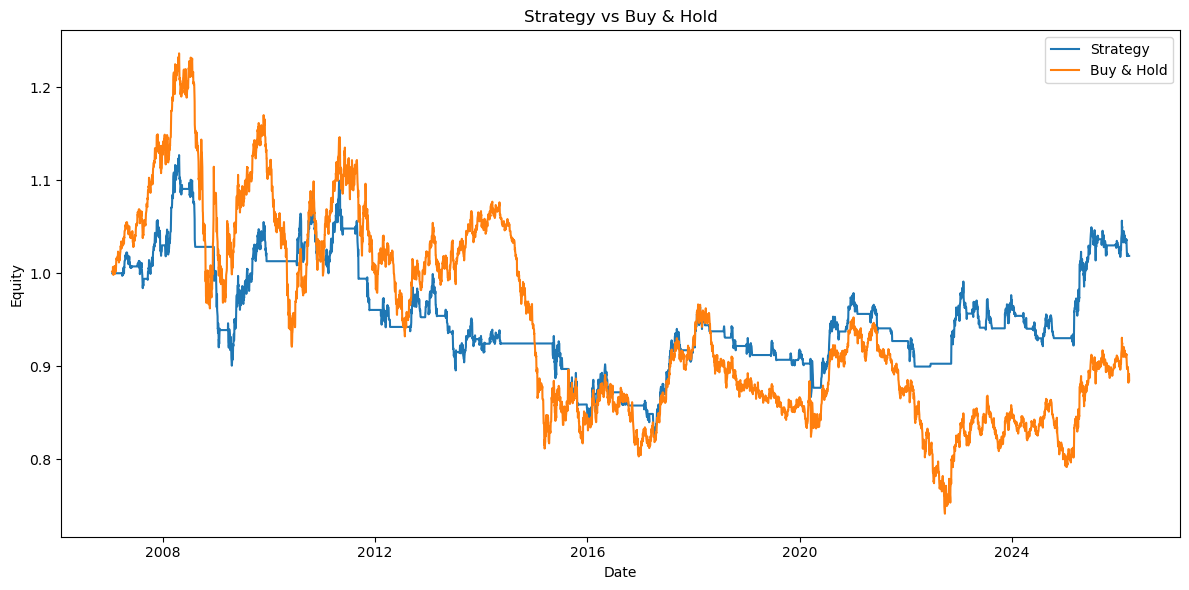

In [6]:
#Visibility: Plot performance
plt.figure(figsize=(12, 6))
plt.plot(df.index, df["strategy_equity"], label="Strategy")
plt.plot(df.index, df["buy_hold"], label="Buy & Hold")

plt.title("Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()

plt.tight_layout()
plt.savefig("outputs/charts/day04_strategy_vs_buyhold.png")
plt.show()

In [7]:
#Strategy Drawdown
rolling_max = df["strategy_equity"].cummax()
df["strategy_drawdown"] = (df["strategy_equity"] - rolling_max) / rolling_max

#Plot Drawdown
rolling_max = df["strategy_equity"].cummax()
df["strategy_drawdown"] = (df["strategy_equity"] - rolling_max) / rolling_max

In [8]:
#Performance Metrics
total_return = df["strategy_equity"].iloc[-1] - 1

annual_return = df["strategy_return"].mean() * 252
annual_vol = df["strategy_return"].std() * np.sqrt(252)

sharpe = annual_return / annual_vol

max_dd = df["strategy_drawdown"].min()

metrics = pd.DataFrame({
    "Metric": [
        "Total Return",
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Max Drawdown"
    ],
    "Value": [
        total_return,
        annual_return,
        annual_vol,
        sharpe,
        max_dd
    ]
})

metrics

,Metric,Value
0,Total Return,0.018680
1,Annual Return,0.002639
2,Annual Volatility,0.058399
3,Sharpe Ratio,0.045181
4,Max Drawdown,-0.265937


In [9]:
#Save Result
metrics.to_csv("outputs/tables/day04_strategy_metrics.csv", index=False)
df.to_csv("outputs/tables/day04_strategy_data.csv")

## Analyst Interpretation

This strategy uses a simple moving average crossover to determine market direction. When the short-term trend moves above the long-term trend, the model enters a long position, and exits when the trend reverses.

The performance comparison shows how the strategy behaves relative to a passive buy-and-hold approach. While the strategy may reduce exposure during unfavorable conditions, it may also miss some profitable periods.

The equity curve illustrates whether the strategy consistently grows capital over time, while the drawdown chart highlights periods of loss and risk exposure.

Overall, the results demonstrate that rule-based strategies can provide structure and discipline, but their effectiveness depends on market conditions and parameter selection.

## Conclusion

This project introduces the concept of backtesting, where trading ideas are evaluated using historical data. While the strategy is simple, it provides a foundation for more advanced models that incorporate multiple signals and risk management techniques.